In [51]:
import os
import sys
sys.path.append(os.path.abspath(".."))
import pandas as pd
from etl.transform import transform
from etl.extractors import extract_data
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [52]:
df=extract_data('../data/processed/cleansuperstoredata.csv')

2026-08-02 18:06:07,273 - etl.extractors - INFO - Loaded 9800 rows and 25 columns


In [53]:
df.isna().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
Order_Year        0
Order_Month       0
Order_Weekday     0
Ship_Year         0
Ship_Month        0
Ship_Weekday      0
Shipping_Days     0
dtype: int64

In [54]:
df.dtypes

Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code      float64
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
Order_Year         int64
Order_Month        int64
Order_Weekday     object
Ship_Year          int64
Ship_Month         int64
Ship_Weekday      object
Shipping_Days      int64
dtype: object

In [55]:
df=transform(df)

2026-08-02 18:06:07,313 - etl.transform - INFO - Transformation started
2026-08-02 18:06:07,320 - etl.transform - INFO - Converted Order_Date to datetime
2026-08-02 18:06:07,325 - etl.transform - INFO - Converted Ship_Date to datetime
2026-08-02 18:06:07,335 - etl.transform - INFO - Added Shipping_Days feature
2026-08-02 18:06:07,336 - etl.transform - INFO - Date-based feature engineering completed
2026-08-02 18:06:07,385 - etl.transform - INFO - Cleaned categorical columns: ['Order_ID', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Order_Weekday', 'Ship_Weekday']
2026-08-02 18:06:07,406 - etl.transform - INFO - Removed duplicates: 0 rows dropped
2026-08-02 18:06:07,406 - etl.transform - INFO - transformation completed


In [56]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Sub_Category,Product_Name,Sales,Order_Year,Order_Month,Order_Weekday,Ship_Year,Ship_Month,Ship_Weekday,Shipping_Days
0,1,ca-2017-152156,2017-08-11,2017-11-11,second class,cg-12520,claire gute,consumer,united states,henderson,...,bookcases,bush somerset collection bookcase,261.9600,2017.0,8.0,friday,2017.0,11.0,saturday,92.0
1,2,ca-2017-152156,2017-08-11,2017-11-11,second class,cg-12520,claire gute,consumer,united states,henderson,...,chairs,"hon deluxe fabric upholstered stacking chairs,...",731.9400,2017.0,8.0,friday,2017.0,11.0,saturday,92.0
2,3,ca-2017-138688,2017-12-06,NaT,second class,dv-13045,darrin van huff,corporate,united states,los angeles,...,labels,self-adhesive address labels for typewriters b...,14.6200,2017.0,12.0,wednesday,NaN,NaN,<NA>,NaN
3,4,us-2016-108966,2016-11-10,NaT,standard class,so-20335,sean o donnel,consumer,united states,fort lauderdale,...,tables,bretford cr4500 series slim rectangular table,957.5775,2016.0,11.0,thursday,NaN,NaN,<NA>,NaN
4,5,us-2016-108966,2016-11-10,NaT,standard class,so-20335,sean o donnel,consumer,united states,fort lauderdale,...,storage,eldon fold n roll cart system,22.3680,2016.0,11.0,thursday,NaN,NaN,<NA>,NaN


In [57]:
df.dtypes

Row_ID                    int64
Order_ID         string[python]
Order_Date       datetime64[ns]
Ship_Date        datetime64[ns]
Ship_Mode        string[python]
Customer_ID      string[python]
Customer_Name    string[python]
Segment          string[python]
Country          string[python]
City             string[python]
State            string[python]
Postal_Code             float64
Region           string[python]
Product_ID       string[python]
Category         string[python]
Sub_Category     string[python]
Product_Name     string[python]
Sales                   float64
Order_Year              float64
Order_Month             float64
Order_Weekday    string[python]
Ship_Year               float64
Ship_Month              float64
Ship_Weekday     string[python]
Shipping_Days           float64
dtype: object

In [58]:
df.isna().sum()

Row_ID              0
Order_ID            0
Order_Date       5841
Ship_Date        5985
Ship_Mode           0
Customer_ID         0
Customer_Name       0
Segment             0
Country             0
City                0
State               0
Postal_Code        11
Region              0
Product_ID          0
Category            0
Sub_Category        0
Product_Name        0
Sales               0
Order_Year       5841
Order_Month      5841
Order_Weekday    5841
Ship_Year        5985
Ship_Month       5985
Ship_Weekday     5985
Shipping_Days    7124
dtype: int64

In [59]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Order_Year', 'Order_Month', 'Order_Weekday',
       'Ship_Year', 'Ship_Month', 'Ship_Weekday', 'Shipping_Days'],
      dtype='object')

In [60]:
if "Shipping_Days" in df.columns:
    df["Shipping_Days"] = df["Shipping_Days"].fillna(df["Shipping_Days"].median())

In [61]:
print("Remaining NaNs in df:")
print(df.isna().sum()[df.isna().sum() > 0])

Remaining NaNs in df:
Order_Date       5841
Ship_Date        5985
Postal_Code        11
Order_Year       5841
Order_Month      5841
Order_Weekday    5841
Ship_Year        5985
Ship_Month       5985
Ship_Weekday     5985
dtype: int64


In [62]:
drop_columns = [
    'Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Product_ID',
    'Customer_Name', 'Order_Year', 'Order_Month', 'Order_Weekday', 'Country', 'State', 'City',
    'Postal_Code', 'Product_Name', 'Ship_Year', 'Ship_Month', 'Ship_Weekday'
]

# Drop unwanted columns
df_models = df.drop(columns=[col for col in drop_columns if col in df.columns], errors="ignore")

In [63]:
df_models.shape

(9800, 6)

In [64]:
X = df_models.drop(columns=['Sales'], errors="ignore")
y = df_models['Sales']

In [65]:
X

,Segment,Region,Category,Sub_Category,Shipping_Days
0,consumer,south,furniture,bookcases,92.0
1,consumer,south,furniture,chairs,92.0
2,corporate,west,office supplies,labels,122.0
3,consumer,south,furniture,tables,122.0
4,consumer,south,office supplies,storage,122.0
...,...,...,...,...,...
9795,corporate,central,office supplies,binders,122.0
9796,corporate,east,office supplies,art,122.0
9797,corporate,east,technology,phones,122.0
9798,corporate,east,technology,phones,122.0


In [66]:
df['Sub_Category'].unique()

<StringArray>
[  'bookcases',      'chairs',      'labels',      'tables',     'storage',
 'furnishings',         'art',      'phones',     'binders',  'appliances',
       'paper', 'accessories',   'envelopes',   'fasteners',    'supplies',
    'machines',     'copiers']
Length: 17, dtype: string

In [67]:
X.isna().sum()

Segment          0
Region           0
Category         0
Sub_Category     0
Shipping_Days    0
dtype: int64

In [68]:
y.isna().sum()

np.int64(0)

In [69]:
categorical_features=X.columns.tolist()
type(categorical_features)

list

In [70]:
X_encoded = pd.get_dummies(X, drop_first=True
                           )
X_encoded

,Shipping_Days,Segment_corporate,Segment_home office,Region_east,Region_south,Region_west,Category_office supplies,Category_technology,Sub_Category_appliances,Sub_Category_art,...,Sub_Category_envelopes,Sub_Category_fasteners,Sub_Category_furnishings,Sub_Category_labels,Sub_Category_machines,Sub_Category_paper,Sub_Category_phones,Sub_Category_storage,Sub_Category_supplies,Sub_Category_tables
0,92.0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,92.0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,122.0,True,False,False,False,True,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,122.0,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,122.0,False,False,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,122.0,True,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9796,122.0,True,False,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
9797,122.0,True,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
9798,122.0,True,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False


In [71]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [72]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)


In [73]:
model=LinearRegression()


In [74]:
model.fit(X_train, y_train)

LinearRegression()

In [75]:
y_pred=model.predict(X_test)

In [76]:

import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 238.98969190088803
RMSE: 741.1078078686927
R2: 0.17827506627816447


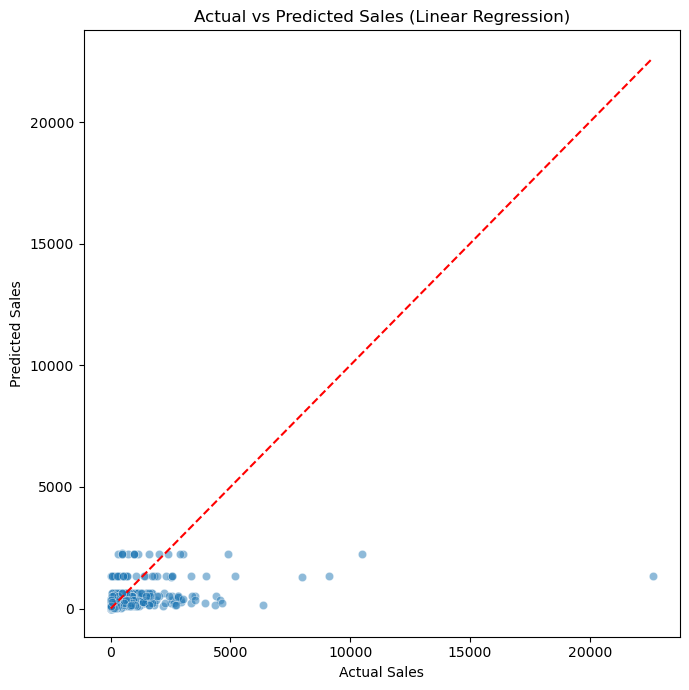

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Linear Regression)")
plt.tight_layout()
plt.show()

# Sales Prediction

## Preprocessing
- Features used: Segment, Category, Sub-Category, Region
- Applied One-Hot Encoding for categorical variables
- StandardScaler applied to encoded features

## Model
- Linear Regression trained on processed data
- Evaluation metrics:
  - MAE: 238.67(On average, predictions are off by about 239 units of sales)
  - RMSE: 740.99( Larger errors exist, showing the model struggles with extreme values.)
  - R²: 0.1785(The model explains only ~18% of the variance in sales, which is quite low.)

## Insights
- The model explains ~18% of variance in sales.
- Predictions are close for small sales values but diverge for large outliers.
- Outliers in sales significantly affect performance.
- Future improvement: try Random Forest or Gradient Boosting to capture non-linear patterns.

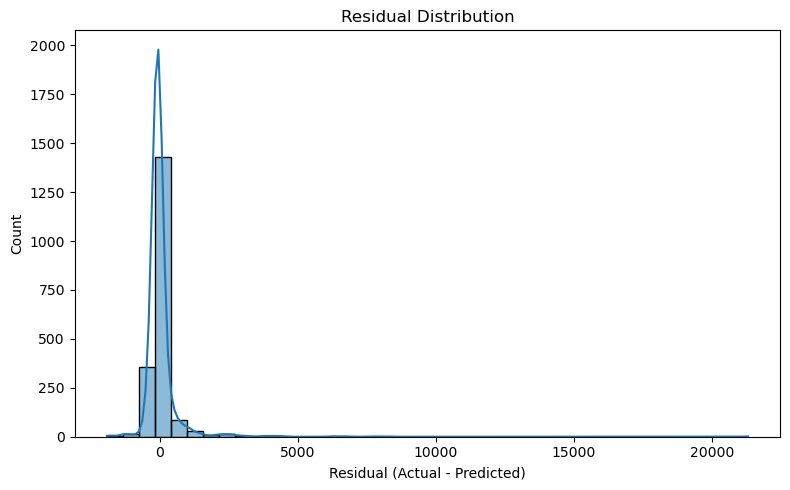

In [78]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

# Residual Analysis

Residuals represent the difference between actual and predicted sales:
residual=actual-predicted

### Residual Distribution
- The histogram shows most residuals clustered around **0**, meaning the model often predicts close to the actual sales.
- The presence of a **long right tail** indicates some large positive residuals (under-predictions), likely caused by high-value outliers in sales.
- The distribution is not perfectly symmetric, suggesting the model struggles more with extreme values than with typical sales.

### Insights
- The model captures general trends but underestimates high sales values.
- Outliers heavily influence prediction accuracy.
- Future improvements could include:
  - **Log transformation** of sales to reduce skew.
  - **Robust regression** or **tree-based models** to handle non-linear patterns.
  - Outlier treatment (capping or winsorizing) to stabilize residuals.


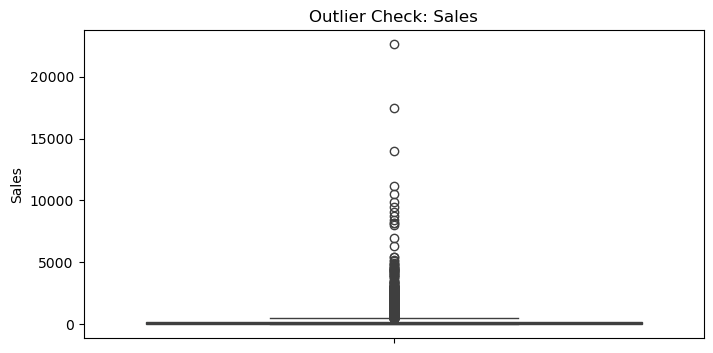

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.boxplot(y)
plt.title("Outlier Check: Sales")
plt.show()

In [80]:
from sklearn.ensemble import RandomForestRegressor

In [81]:
rf_model = RandomForestRegressor(
    n_estimators=200,       # number of trees
    max_depth=None,         # let trees grow fully
    min_samples_leaf=2,     # avoid overfitting
    random_state=42,
    n_jobs=-1               # use all cores
)

In [83]:
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

In [84]:

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 245.40748958477872
Random Forest RMSE: 770.9710180329131
Random Forest R2: 0.11071740447599032


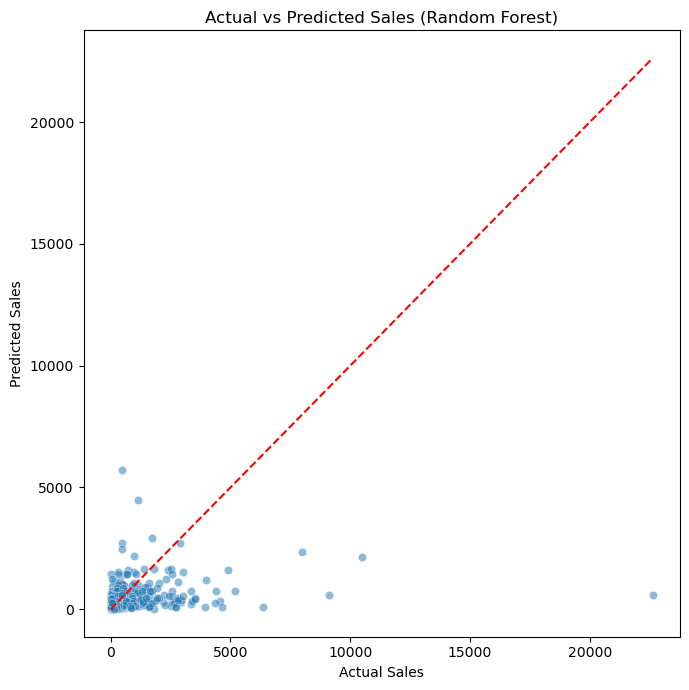

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.tight_layout()
plt.show()


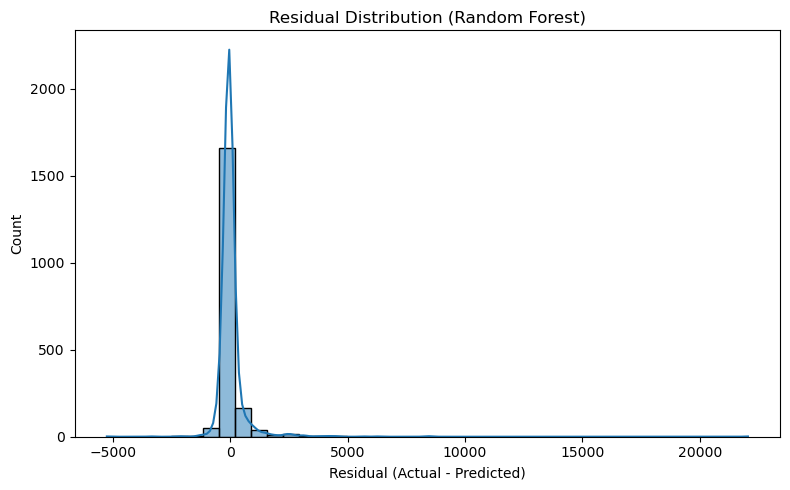

In [86]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(8, 5))
sns.histplot(residuals_rf, bins=40, kde=True)
plt.title("Residual Distribution (Random Forest)")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()


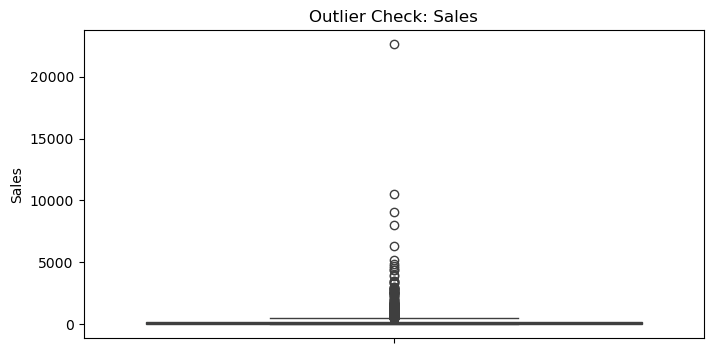

In [87]:
plt.figure(figsize=(8, 4))
sns.boxplot(y=y_test)
plt.title("Outlier Check: Sales")
plt.show()
